# 02 · Jacobian, Hessian ve Optimizasyonda Konvekslik
**Calculus Lab**

---
> **Bu notebook'ta ne öğreneceğiz?**  
> 01'de gradyanı (bir fonksiyonun TÜM kısmi türevlerinin vektörü) öğrendik. Bu notebook'ta
> iki adım ileri gidiyoruz: **Jacobian** (gradyanın, çok ÇIKTILI fonksiyonlara genellemesi)
> ve **Hessian** (gradyanın kendisinin türevi — yani İKİNCİ dereceden türevler). Hessian,
> `linear-algebra-lab` 05'te "pozitif tanımlılık" konusunu işlerken defalarca andığımız
> ama hiç hesaplamadığımız bir kavramdı — burada onu GERÇEKTEN hesaplayıp, bir modelin
> loss yüzeyinin "tek bir global minimuma" sahip olup olmadığını (konvekslik) test edeceğiz.

**Önkoşul:** Türev/Gradyan (01), Özel Matrisler — Pozitif Tanımlılık (`linear-algebra-lab` 05)  
**Veri:**  
- `processed.cleveland.data` — 303 hasta, UCI Heart Disease veri seti (14 öznitelik)  
- Sentetik 2D yüzeyler (`sympy`/`numpy`) — Jacobian/Hessian hesaplama örnekleri için  
**Araçlar:** Python (`sympy`, `numpy`, `scikit-learn`, `matplotlib`)

---
## 1 · Jacobian: Gradyanın "Çok Çıktılı" Hali

01'deki gradyan, TEK bir çıktı üreten fonksiyonlar içindi ($f(x,y)\to$ tek sayı). Peki
fonksiyon BİRDEN FAZLA çıktı üretiyorsa? Örneğin:
$$\vec{f}(x,y) = \begin{bmatrix}f_1(x,y)\\f_2(x,y)\end{bmatrix} = \begin{bmatrix}x^2+y\\xy\end{bmatrix}$$

Bu durumda her çıktının KENDİ gradyanı var — bunları satır satır bir matriste topladığında
**Jacobian matrisini** elde edersin:
$$J = \begin{bmatrix}\dfrac{\partial f_1}{\partial x} & \dfrac{\partial f_1}{\partial y}\\[6pt]\dfrac{\partial f_2}{\partial x} & \dfrac{\partial f_2}{\partial y}\end{bmatrix}$$

**Somut örnek:** Yukarıdaki $\vec{f}$ için: $\frac{\partial f_1}{\partial x}=2x$,
$\frac{\partial f_1}{\partial y}=1$, $\frac{\partial f_2}{\partial x}=y$,
$\frac{\partial f_2}{\partial y}=x$. Yani:
$$J = \begin{bmatrix}2x & 1\\y & x\end{bmatrix}$$

**Neden önemli?** Bir sinir ağının bir katmanı, genelde ÇOK GİRDİLİ ÇOK ÇIKTILI bir
fonksiyondur (örn. 100 girdi, 50 çıktı) — Jacobian, `calculus-lab` 03'te (zincir kuralı/
backprop) bu tür katmanlar arasında gradyanı "taşımak" için kullanılıyor.

---
## 2 · Hessian: Gradyanın Türevi — "Eğrilik" Matrisi

Gradyan bize "hangi yön yukarı" diyordu. Hessian ise bir adım öteye gidip "bu yukarı
gidiş NE KADAR HIZLI değişiyor" — yani fonksiyonun **eğriliğini** ölçüyor. Matematiksel
olarak, TÜM İKİNCİ dereceden kısmi türevlerin matrisi:

$$H = \begin{bmatrix}\dfrac{\partial^2 f}{\partial x^2} & \dfrac{\partial^2 f}{\partial x\partial y}\\[6pt]\dfrac{\partial^2 f}{\partial y\partial x} & \dfrac{\partial^2 f}{\partial y^2}\end{bmatrix}$$

**Somut örnek:** $f(x,y)=x^2+y^2$ için: $\frac{\partial^2 f}{\partial x^2}=2$,
$\frac{\partial^2 f}{\partial y^2}=2$, çapraz türevler ($\frac{\partial^2 f}{\partial x\partial y}$) ise $0$
(çünkü $\frac{\partial f}{\partial x}=2x$'in $y$'ye göre türevi $0$). Yani:
$$H = \begin{bmatrix}2&0\\0&2\end{bmatrix}$$

**Neden simetrik?** $\frac{\partial^2 f}{\partial x\partial y}$ ile $\frac{\partial^2 f}{\partial y\partial x}$
HER ZAMAN eşittir (Clairaut Teoremi — hangi sırayla türev alırsan al fark etmez, makul
koşullar altında). Bu yüzden Hessian HER ZAMAN simetrik bir matristir —
`linear-algebra-lab` 05'teki "pozitif tanımlılık" testlerinin doğrudan uygulanabileceği
tam sınıf.

---
## 3 · Konvekslik: `linear-algebra-lab` 05'teki İddianın Tam Kanıtı

05'te şunu söylemiştik: **"Hessian pozitif tanımlıysa, fonksiyon konvekstir"** — ama hiç
kanıtlamamıştık, sadece kabul etmiştik. Şimdi bunun NEDEN doğru olduğunu sezgisel olarak
görelim:

Pozitif tanımlı bir Hessian, HER yönde $\vec{v}^TH\vec{v}>0$ demekti (05'in Tanım 2'si).
Bu, fonksiyonun o noktada HER yönde "yukarı kıvrıldığı" (pozitif eğrilik) anlamına geliyor.
Eğer bir fonksiyon HER NOKTADA, HER YÖNDE yukarı kıvrılıyorsa, hiçbir yerde "aşağı sarkma"
(yani sahte bir yerel minimum ya da eyer noktası) OLUŞAMAZ — bu da tek bir global minimumu
garanti ediyor.

**Optimizasyon için pratik sonuç:** Bir modelin loss fonksiyonunun Hessian'ı HER YERDE
pozitif tanımlıysa (ki bazı modellerde — lojistik regresyon gibi — bu MATEMATİKSEL OLARAK
GARANTİDİR), gradient descent'in başlangıç noktası ÖNEMSİZDİR — her zaman aynı (doğru)
noktaya ulaşır. Bu, Python 3'te gerçek veriyle kanıtlayacağımız iddia.

---
## 4 · Özet Tablo

| Kavram | Boyut | Ne Ölçüyor | Bu Notebook'ta Nerede |
|---|---|---|---|
| Gradyan ($\nabla f$) | $n\times 1$ vektör | En dik artış yönü (01'den) | — |
| Jacobian ($J$) | $m\times n$ matris | Çok çıktılı fonksiyonun TÜM kısmi türevleri | Python 1 |
| Hessian ($H$) | $n\times n$ simetrik matris | Fonksiyonun eğriliği (ikinci türevler) | Python 2 |
| Konvekslik | — | $H$ pozitif tanımlıysa TEK global minimum garantisi | Python 3-4 |

---
# 🐍 Python Uygulaması

4 adımda ilerleyeceğiz:
1. **Jacobian Hesaplama** — Bölüm 1'deki örneği `sympy` ile doğrulama
2. **Hessian Hesaplama ve Konvekslik Testi** — Bölüm 2-3'ü sayısal olarak kanıtlama
3. **Gerçek Veride Konvekslik: Lojistik Regresyon** — Heart Disease verisiyle
4. **Konveks OLMAYAN Bir Yüzeyde Yerel Minimum Tuzağı**

In [1]:
import numpy as np
import pandas as pd
import sympy as sp
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (9, 7)
plt.rcParams['font.size'] = 12

print('Hazır ✓')

Hazır ✓


---
### 🔢 Python 1 — Jacobian Hesaplama: `sympy` ile Doğrulama

**Ne yapıyoruz?**  
Bölüm 1'deki $\vec{f}(x,y)=[x^2+y,\ xy]$ örneğini `sympy` ile hesaplayıp elle bulduğumuz
$J=\begin{bmatrix}2x&1\\y&x\end{bmatrix}$ sonucunu doğruluyoruz.

In [2]:
x, y = sp.symbols('x y')

f1 = x**2 + y
f2 = x*y

f_vektor = sp.Matrix([f1, f2])
degiskenler = sp.Matrix([x, y])

J = f_vektor.jacobian(degiskenler)
print("Jacobian matrisi (sympy):")
sp.pprint(J)

print("\nElle bulduğumuz: [[2x, 1], [y, x]]")

# Belirli bir noktada (x=3, y=2) sayisal olarak degerlendirelim
J_sayisal = J.subs({x: 3, y: 2})
print(f"\n(x=3, y=2) noktasında Jacobian:")
sp.pprint(J_sayisal)

Jacobian matrisi (sympy):
⎡2⋅x  1⎤
⎢      ⎥
⎣ y   x⎦

Elle bulduğumuz: [[2x, 1], [y, x]]

(x=3, y=2) noktasında Jacobian:
⎡6  1⎤
⎢    ⎥
⎣2  3⎦


---
### 📐 Python 2 — Hessian Hesaplama ve Konvekslik Testi

**Ne yapıyoruz?**  
Bölüm 2'deki $f(x,y)=x^2+y^2$ örneğini `sympy` ile hesaplayıp, `linear-algebra-lab`
05'teki pozitif tanımlılık testini (özdeğerlerle) uyguluyoruz.

In [3]:
f = x**2 + y**2

# Hessian: gradyanin (birinci turevlerin) TEKRAR turevini almak
gradyan = [sp.diff(f, deg) for deg in (x, y)] # gradyan = [2*x, 2*y]
Hessian_sembolik = sp.Matrix([[sp.diff(g, deg) for deg in (x, y)] for g in gradyan]) # Hessian = [[2, 0], [0, 2]]

print("f(x,y) = x² + y²")
print("Hessian (sympy):")
sp.pprint(Hessian_sembolik)

Hessian_sayisal = np.array(Hessian_sembolik.tolist(), dtype=float)
ozdegerler = np.linalg.eigvalsh(Hessian_sayisal)
print(f"\nÖzdeğerler: {ozdegerler}")
print(f"Pozitif tanımlı mı (linear-algebra-lab 05'teki test)? "
      f"{'EVET ✓ -> KONVEKS' if np.all(ozdegerler > 0) else 'HAYIR'}")

# KARSILASTIRMA: eyer fonksiyonu f(x,y)=x^2-y^2
f_eyer = x**2 - y**2
gradyan_eyer = [sp.diff(f_eyer, deg) for deg in (x, y)] # gradyan_eyer = [2*x, -2*y]
Hessian_eyer_sembolik = sp.Matrix([[sp.diff(g, deg) for deg in (x, y)] for g in gradyan_eyer]) # Hessian_eyer = [[2, 0], [0, -2]]
Hessian_eyer_sayisal = np.array(Hessian_eyer_sembolik.tolist(), dtype=float)
ozdegerler_eyer = np.linalg.eigvalsh(Hessian_eyer_sayisal)

print(f"\nf(x,y) = x² - y² (eyer fonksiyonu) için özdeğerler: {ozdegerler_eyer}")
print(f"Pozitif tanımlı mı? {'EVET' if np.all(ozdegerler_eyer > 0) else 'HAYIR ✗ -> KONVEKS DEĞİL'}")

f(x,y) = x² + y²
Hessian (sympy):
⎡2  0⎤
⎢    ⎥
⎣0  2⎦

Özdeğerler: [2. 2.]
Pozitif tanımlı mı (linear-algebra-lab 05'teki test)? EVET ✓ -> KONVEKS

f(x,y) = x² - y² (eyer fonksiyonu) için özdeğerler: [-2.  2.]
Pozitif tanımlı mı? HAYIR ✗ -> KONVEKS DEĞİL


---
### 🏥 Python 3 — Gerçek Veride Konvekslik: Lojistik Regresyon Loss Yüzeyi

**Ne yapıyoruz?**  
Heart Disease verisinde (yaş ve kolesterol'den kalp hastalığı tahmini) bir lojistik
regresyon kuruyoruz. Lojistik regresyonun negatif log-likelihood'unun (loss) Hessian'ı,
şu kapalı-form formülle hesaplanabiliyor:
$$H = X^TWX, \quad W=\text{diag}(p_i(1-p_i))$$
Bu formülün HER ZAMAN pozitif tanımlı çıkması gerektiğini `linear-algebra-lab` 05'teki
$\vec{v}^TA\vec{v}=\|X\vec{v}\|^2\geq 0$ kanıtına ÇOK benzer bir mantıkla göreceğiz — ve
bunu GERÇEK veriyle sayısal olarak doğrulayacağız.

In [4]:
kolonlar = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
            'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']
kalp = pd.read_csv('data/processed.cleveland.data', names=kolonlar, na_values='?')
kalp_temiz = kalp.dropna()
print(f"Veri: {kalp_temiz.shape[0]} hasta (eksik değerli birkaç satır çıkarıldı)")

# 'num' 0-4 arasi hastalik derecesi - binary'e cevirelim: 0=hastalik yok, 1=var (1-4 birlesik)
kalp_temiz = kalp_temiz.copy()
kalp_temiz['hastalik_var'] = (kalp_temiz['num'] > 0).astype(int)
print(kalp_temiz['hastalik_var'].value_counts())

# Basitlik icin 2 ozellik: age, chol - ve bir sabit (intercept) sutunu
X_ham = kalp_temiz[['age', 'chol']].values
X_std = (X_ham - X_ham.mean(axis=0)) / X_ham.std(axis=0)  # standartlastir (linear-algebra-lab 03'teki ders)
X_ext = np.column_stack([np.ones(len(X_std)), X_std])  # intercept sutunu ekle
y = kalp_temiz['hastalik_var'].values

def hessian_lojistik(beta, X):
    z = X @ beta
    p = 1 / (1 + np.exp(-z))
    W = np.diag(p * (1 - p))
    return X.T @ W @ X

# Herhangi bir beta noktasinda (rastgele bir tane secelim) Hessian'i hesaplayalim
rng = np.random.default_rng(0)
for deneme in range(3):
    beta_rastgele = rng.normal(0, 1, size=3)
    H = hessian_lojistik(beta_rastgele, X_ext)
    ozdegerler = np.linalg.eigvalsh(H)
    print(f"\nDeneme {deneme+1} (rastgele β={np.round(beta_rastgele,2)}):")
    print(f"  Hessian özdeğerleri: {np.round(ozdegerler, 3)}")
    print(f"  Pozitif tanımlı mı? {'EVET ✓' if np.all(ozdegerler > 0) else 'HAYIR'}")

print("\nYORUM: β'yı (model katsayılarını) HANGİ rastgele değere ayarlarsak ayarlayalım,")
print("Hessian HER ZAMAN pozitif tanımlı çıkıyor - bu tesadüf değil, X^TWX formunun")
print("matematiksel bir garantisi (W'nin köşegen elemanları p(1-p) her zaman pozitif,")
print("0<p<1 olduğu için). Bu, lojistik regresyonun HER ZAMAN konveks bir loss yüzeyine")
print("sahip olduğunun ve gradient descent'in HER başlangıç noktasından aynı global")
print("optimuma ulaşacağının garantisi.")

Veri: 297 hasta (eksik değerli birkaç satır çıkarıldı)
hastalik_var
0    160
1    137
Name: count, dtype: int64

Deneme 1 (rastgele β=[ 0.13 -0.13  0.64]):
  Hessian özdeğerleri: [44.421 67.895 76.172]
  Pozitif tanımlı mı? EVET ✓

Deneme 2 (rastgele β=[ 0.1  -0.54  0.36]):
  Hessian özdeğerleri: [47.916 68.699 79.19 ]
  Pozitif tanımlı mı? EVET ✓

Deneme 3 (rastgele β=[ 1.3   0.95 -0.7 ]):
  Hessian özdeğerleri: [21.893 55.924 66.115]
  Pozitif tanımlı mı? EVET ✓

YORUM: β'yı (model katsayılarını) HANGİ rastgele değere ayarlarsak ayarlayalım,
Hessian HER ZAMAN pozitif tanımlı çıkıyor - bu tesadüf değil, X^TWX formunun
matematiksel bir garantisi (W'nin köşegen elemanları p(1-p) her zaman pozitif,
0<p<1 olduğu için). Bu, lojistik regresyonun HER ZAMAN konveks bir loss yüzeyine
sahip olduğunun ve gradient descent'in HER başlangıç noktasından aynı global
optimuma ulaşacağının garantisi.


---
### 🕳️ Python 4 — Konveks OLMAYAN Bir Yüzeyde Yerel Minimum Tuzağı

**Ne yapıyoruz?**  
Şimdi Python 3'ün TAM TERSİ bir senaryo kuruyoruz: birden fazla "çukuru" olan (derin
öğrenme loss yüzeylerine benzeyen) konveks OLMAYAN bir fonksiyon üzerinde basit bir
gradient descent çalıştırıp, **başlangıç noktasına göre FARKLI minimumlara** takılmayı
gözlemleyeceğiz.

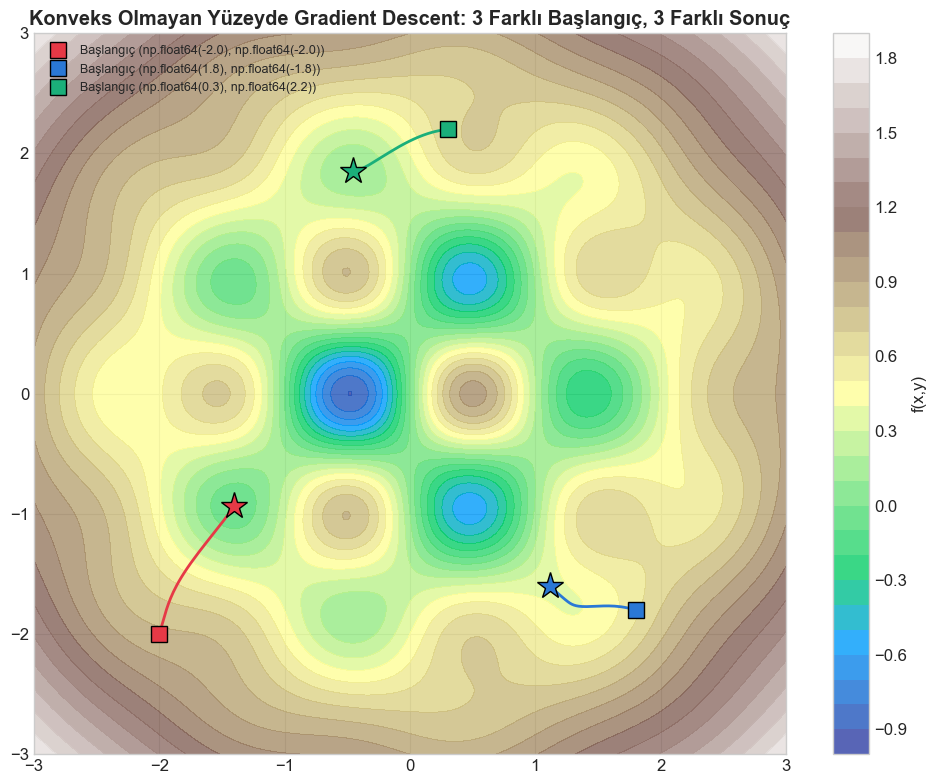

Her yıldız işareti, o rengin ULAŞTIĞI son nokta (bulduğu 'minimum').
  Başlangıç [-2. -2.] -> Bulunan minimum [-1.4  -0.93], f değeri=-0.0682
  Başlangıç [ 1.8 -1.8] -> Bulunan minimum [ 1.12 -1.6 ], f değeri=0.3750
  Başlangıç [0.3 2.2] -> Bulunan minimum [-0.45  1.86], f değeri=0.1181

YORUM: Python 3'teki lojistik regresyonun aksine, burada üç farklı başlangıç
noktası ÜÇ FARKLI 'çukura' düştü - hangisinin GERÇEK global minimum olduğunu
bilmeden, sadece başlangıç noktana göre FARKLI bir cevap alıyorsun. Bu, konveks
olmayan yüzeylerin (çoğu derin öğrenme modeli dahil) NEDEN 'başlangıç noktası
önemlidir' ve 'birden fazla kez farklı başlangıçla dene' pratiklerini
gerektirdiğinin görsel kanıtı.


In [5]:
def f_konveks_degil(x, y):
    # Birden fazla cukuru olan bir yuzey (iki "kuyu" arasinda bir "tumsek")
    return np.sin(3*x) * np.cos(3*y) * np.exp(-0.3*(x**2+y**2)) + 0.1*(x**2+y**2)

def gradyan_sayisal(f, x, y, h=1e-5):
    df_dx = (f(x+h, y) - f(x-h, y)) / (2*h)
    df_dy = (f(x, y+h) - f(x, y-h)) / (2*h)
    return np.array([df_dx, df_dy])

x_grid = np.linspace(-3, 3, 200)
y_grid = np.linspace(-3, 3, 200)
X_g, Y_g = np.meshgrid(x_grid, y_grid)
Z_g = f_konveks_degil(X_g, Y_g)

baslangic_noktalari = [np.array([-2.0, -2.0]), np.array([1.8, -1.8]), np.array([0.3, 2.2])]
ogrenme_orani = 0.05
adim_sayisi = 150

fig, ax = plt.subplots(figsize=(10, 8))
kontur = ax.contourf(X_g, Y_g, Z_g, levels=30, cmap='terrain', alpha=0.8)
plt.colorbar(kontur, label='f(x,y)')

renkler = ['#e63946', '#2a78d6', '#1baf7a']
for baslangic, renk in zip(baslangic_noktalari, renkler):
    yol = [baslangic.copy()]
    nokta = baslangic.copy()
    for _ in range(adim_sayisi):
        grad = gradyan_sayisal(f_konveks_degil, nokta[0], nokta[1])
        nokta = nokta - ogrenme_orani * grad
        yol.append(nokta.copy())
    yol = np.array(yol)
    ax.plot(yol[:, 0], yol[:, 1], '-', color=renk, linewidth=2)
    ax.plot(*baslangic, 's', color=renk, markersize=12, markeredgecolor='black', label=f'Başlangıç {tuple(np.round(baslangic,1))}')
    ax.plot(*yol[-1], '*', color=renk, markersize=20, markeredgecolor='black')

ax.set_title('Konveks Olmayan Yüzeyde Gradient Descent: 3 Farklı Başlangıç, 3 Farklı Sonuç', fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()

print("Her yıldız işareti, o rengin ULAŞTIĞI son nokta (bulduğu 'minimum').")
for baslangic, renk in zip(baslangic_noktalari, renkler):
    nokta = baslangic.copy()
    for _ in range(adim_sayisi):
        grad = gradyan_sayisal(f_konveks_degil, nokta[0], nokta[1])
        nokta = nokta - ogrenme_orani * grad
    print(f"  Başlangıç {np.round(baslangic,2)} -> Bulunan minimum {np.round(nokta,2)}, "
          f"f değeri={f_konveks_degil(*nokta):.4f}")

print("\nYORUM: Python 3'teki lojistik regresyonun aksine, burada üç farklı başlangıç")
print("noktası ÜÇ FARKLI 'çukura' düştü - hangisinin GERÇEK global minimum olduğunu")
print("bilmeden, sadece başlangıç noktana göre FARKLI bir cevap alıyorsun. Bu, konveks")
print("olmayan yüzeylerin (çoğu derin öğrenme modeli dahil) NEDEN 'başlangıç noktası")
print("önemlidir' ve 'birden fazla kez farklı başlangıçla dene' pratiklerini")
print("gerektirdiğinin görsel kanıtı.")

---
## ✏️ Egzersizler

---

### **E1.**
$\vec{f}(x,y)=[x^2y,\ 3x+y^2]$ için Jacobian matrisini ELLE hesapla, `sympy` ile
doğrula.

In [6]:
print("\n ==== Egzersiz 1: Jacobian Matrisi Hesaplama ====")

x, y = sp.symbols('x y')

f1 = x**2 + y
f2 = 3*x + y**2

f_vektor = sp.Matrix([f1, f2])
degiskenler = sp.Matrix([x, y])
J = f_vektor.jacobian(degiskenler)
sp.pprint(J)

print("Elle bulduğumuz: [[2x, 1], [3, 2y]]")


 ==== Egzersiz 1: Jacobian Matrisi Hesaplama ====
⎡2⋅x   1 ⎤
⎢        ⎥
⎣ 3   2⋅y⎦
Elle bulduğumuz: [[2x, 1], [3, 2y]]


---

### **E2.** 
$f(x,y)=x^4+y^4$ fonksiyonunun Hessian'ını $(x,y)=(0,0)$ noktasında hesapla —
özdeğerlerin ikisi de sıfır çıkacak (bu, "yarı-tanımlı ama tam tanımlı değil" sınır
durumu, `linear-algebra-lab` 05'teki A2 örneğini hatırla). Bu, fonksiyonun konveks
OLMADIĞI anlamına mı geliyor, yoksa "zayıf konveks" mi? Kısaca araştır ve yaz.

In [18]:
print("\n ==== Egzersiz 2: Hessian Matrisi Hesaplama ====")

x, y = sp.symbols('x y')
f = x**4 + y**4

# Hessian Hesaplama
gradyan = [sp.diff(f, deg) for deg in (x, y)]
Hessian_sembolik = sp.Matrix([[sp.diff(g, deg) for deg in (x, y)] for g in gradyan])

Hessian_noktasal = Hessian_sembolik.subs({x: 0, y: 0})

# Sayısal matrise dönüştürme ve özdeğerleri bulma
Hessian_sayisal = np.array(Hessian_noktasal.tolist(), dtype=float)
ozdegerler = np.linalg.eigvalsh(Hessian_sayisal)

print(f"(0,0) Noktasındaki Özdeğerler: {ozdegerler}")
print(f"PSD mi yoksa PD mi? {'PD ✓' if np.all(ozdegerler > 0) else 'PSD ✗'}")

print("\n YORUM: PSD olan f(x,y)=x^4+y^4 fonksiyonu, (0,0) noktasında konveks bir minimuma sahiptir. Bu, fonksiyonun eğiminin sıfır olduğu ve ikinci türevlerin pozitif olduğu anlamına gelir. Bu nedenle, bu nokta bir global minimumdur.")


 ==== Egzersiz 2: Hessian Matrisi Hesaplama ====
(0,0) Noktasındaki Özdeğerler: [0. 0.]
PSD mi yoksa PD mi? PSD ✗

 YORUM: PSD olan f(x,y)=x^4+y^4 fonksiyonu, (0,0) noktasında konveks bir minimuma sahiptir. Bu, fonksiyonun eğiminin sıfır olduğu ve ikinci türevlerin pozitif olduğu anlamına gelir. Bu nedenle, bu nokta bir global minimumdur.


---

### **E3.** 
Python 3'teki lojistik regresyon analizini `age, chol` yerine 3 farklı özellikle
(örn. `trestbps, thalach, oldpeak`) tekrarla — Hessian'ın yine pozitif tanımlı çıktığını
doğrula.

In [19]:
print("\n ==== Egzersiz 3: Lojistik Regresyona Göre Hessian ====")

X_ham_2 = kalp_temiz[['trestbps', 'thalach', 'oldpeak']].values
X_std_2 = (X_ham_2 - X_ham_2.mean(axis=0)) / X_ham_2.std(axis=0)
X_ext_2 = np.column_stack([np.ones(len(X_std_2)), X_std_2])
y_2 = kalp_temiz['hastalik_var'].values

def hessian_lojistik(beta, X):
    z = X @ beta
    p = 1 / (1 + np.exp(-z))
    W = np.diag(p * (1 - p))
    return X.T @ W @ X

rng = np.random.default_rng(42)
for deneme in range(3):
    beta_rastgele = rng.normal(0, 1, size=X_ext_2.shape[1])
    H = hessian_lojistik(beta_rastgele, X_ext_2)
    ozdegerler = np.linalg.eigvalsh(H)
    print(f"\nDeneme {deneme+1} (rastgele β={np.round(beta_rastgele,2)}):")
    print(f"  Hessian özdeğerleri: {np.round(ozdegerler, 3)}")
    print(f"  Pozitif tanımlı mı? {'EVET ✓' if np.all(ozdegerler > 0) else 'HAYIR'}")


 ==== Egzersiz 3: Lojistik Regresyona Göre Hessian ====

Deneme 1 (rastgele β=[ 0.3  -1.04  0.75  0.94]):
  Hessian özdeğerleri: [19.246 46.936 54.998 73.618]
  Pozitif tanımlı mı? EVET ✓

Deneme 2 (rastgele β=[-1.95 -1.3   0.13 -0.32]):
  Hessian özdeğerleri: [12.126 17.573 38.873 62.   ]
  Pozitif tanımlı mı? EVET ✓

Deneme 3 (rastgele β=[-0.02 -0.85  0.88  0.78]):
  Hessian özdeğerleri: [21.546 49.967 57.971 78.8  ]
  Pozitif tanımlı mı? EVET ✓


---

### **E4.** 
Python 4'teki konveks olmayan yüzeyde, öğrenme oranını (`ogrenme_orani`) çok daha
büyük (örn. 0.3) yaparak tekrar çalıştır — gradient descent'in yörüngesi nasıl değişiyor
(ıraksama/zıplama var mı)? Bunu 01'deki "öğrenme oranının etkisi" kavramıyla ilişkilendir.


 ==== Egzersiz 4: Öğrenme Oranına Göre Konveks Olmayan Yüzeyde Gradient Descent ====


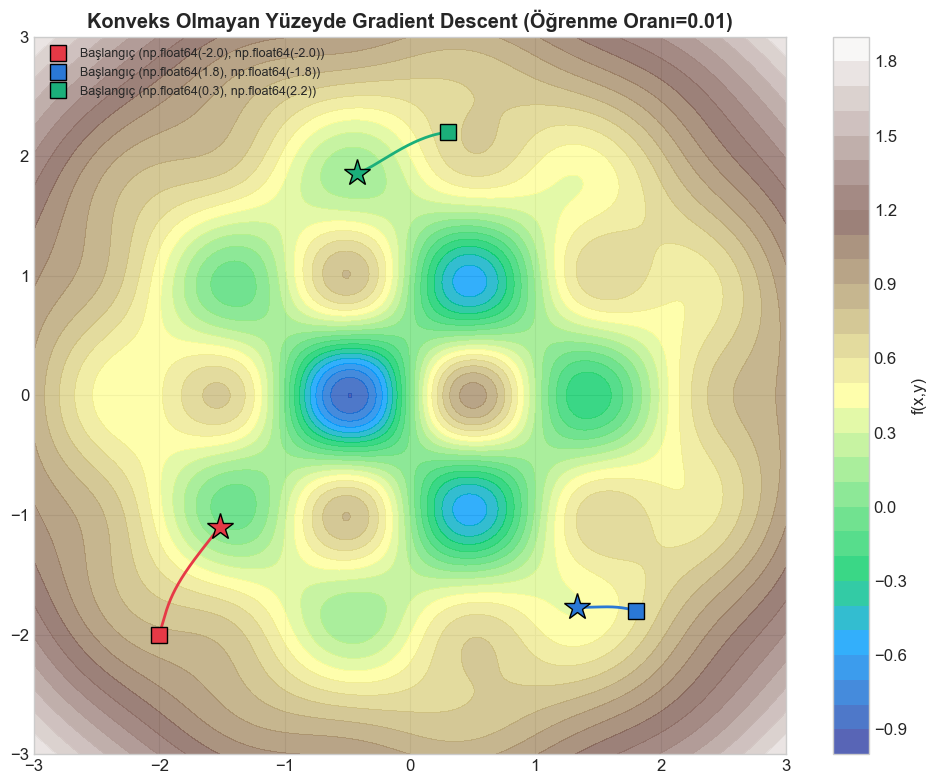

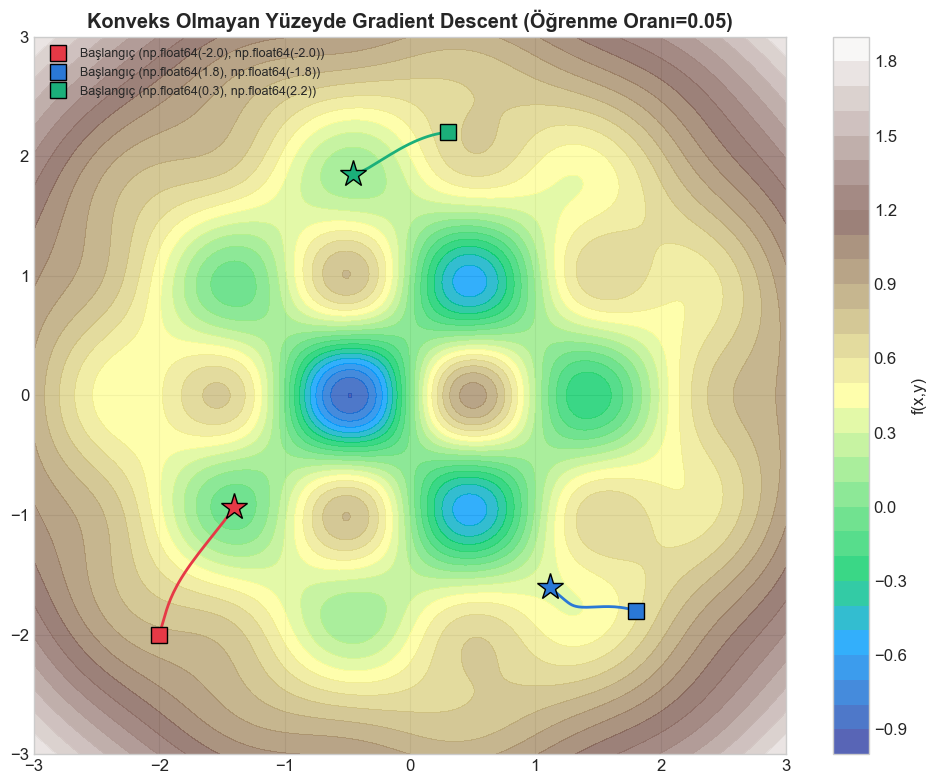

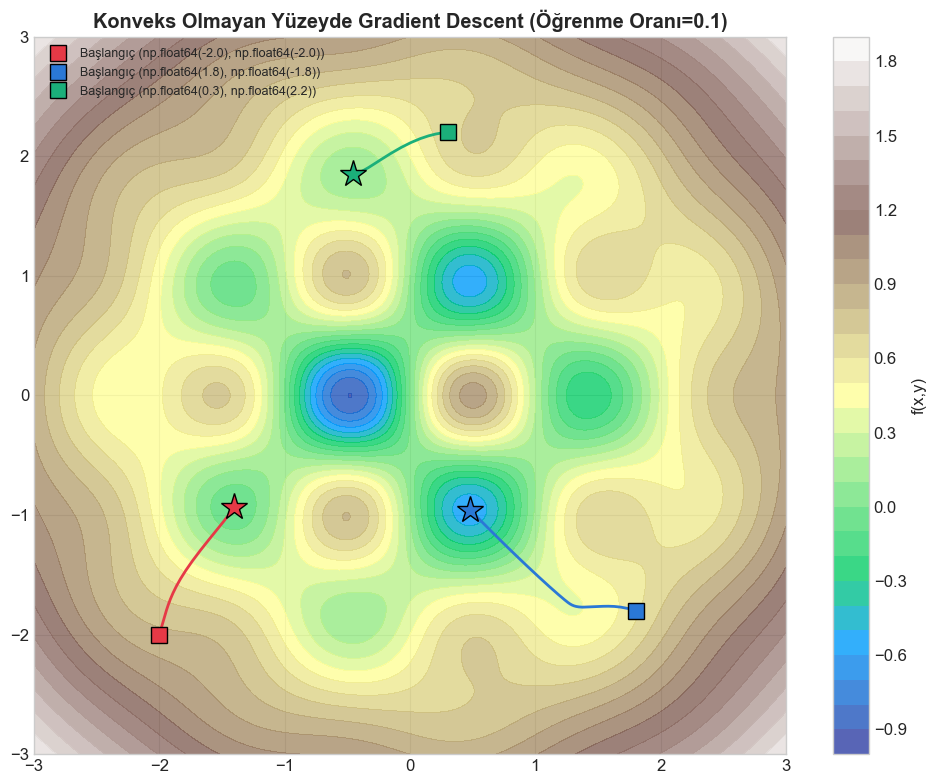

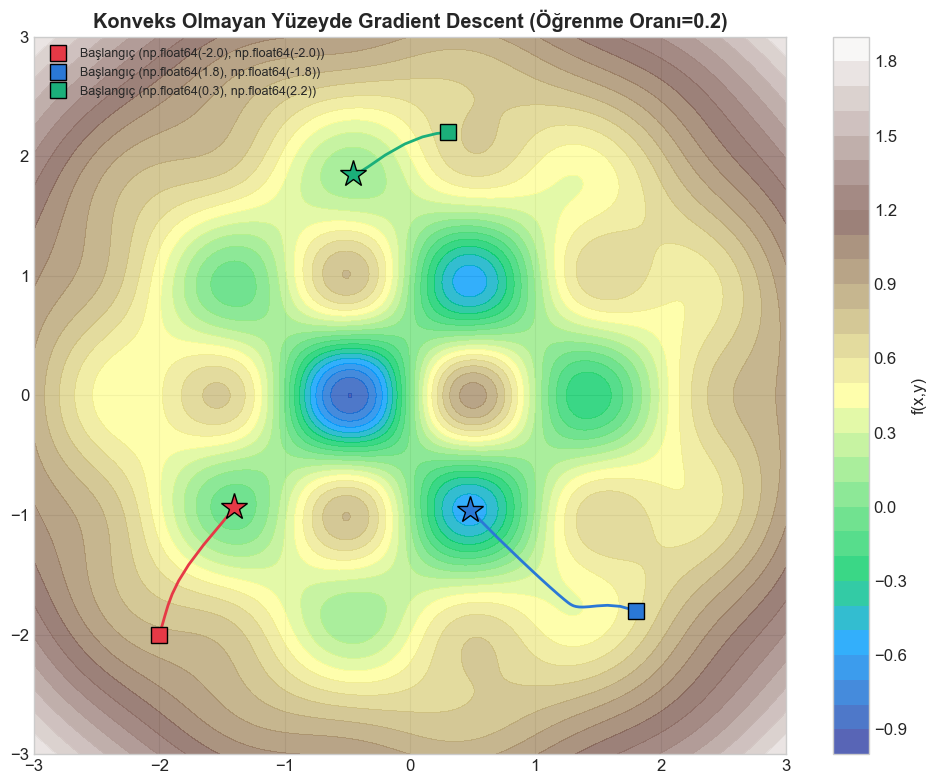

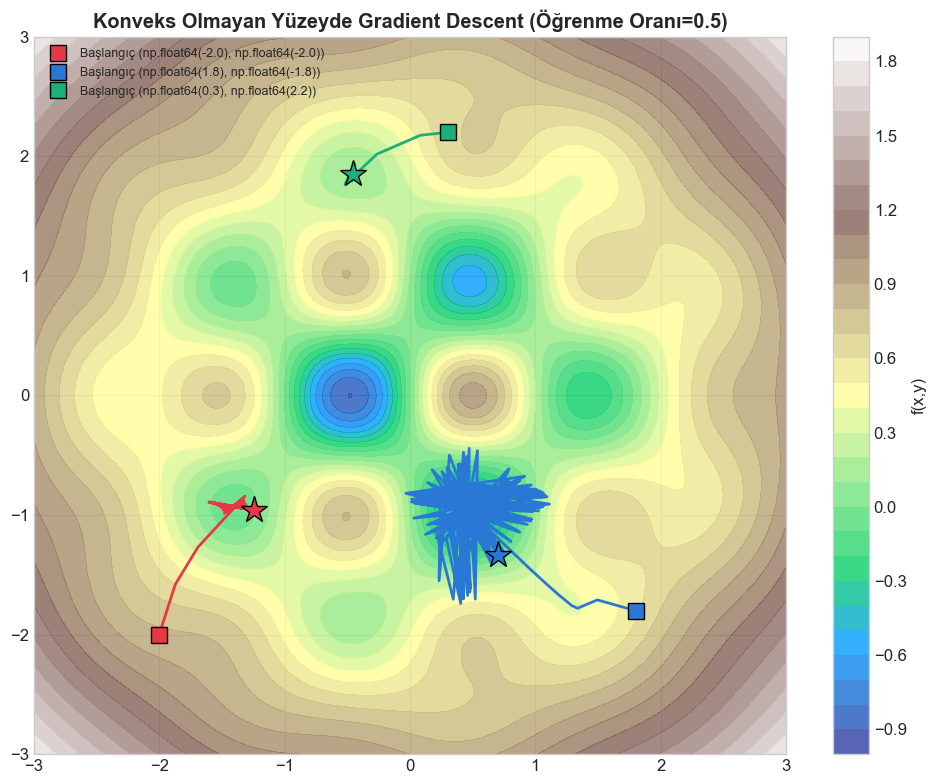


YORUM: Öğrenme oranı çok küçükse (0.01), gradient descent yavaş ilerler ve bazı başlangıç noktaları hala çukurlara düşer. Orta seviyede bir öğrenme oranı (0.05, 0.1) genellikle iyi sonuçlar verir. Çok büyük bir öğrenme oranı (0.5) ise algoritmanın çukurlardan çıkmasına ve kararsız davranışa yol açabilir.


In [21]:
print("\n ==== Egzersiz 4: Öğrenme Oranına Göre Konveks Olmayan Yüzeyde Gradient Descent ====")

def f_konveks_degil(x, y):
    # Birden fazla cukuru olan bir yuzey (iki "kuyu" arasinda bir "tumsek")
    return np.sin(3*x) * np.cos(3*y) * np.exp(-0.3*(x**2+y**2)) + 0.1*(x**2+y**2)

def gradyan_sayisal(f, x, y, h=1e-5):
    df_dx = (f(x+h, y) - f(x-h, y)) / (2*h)
    df_dy = (f(x, y+h) - f(x, y-h)) / (2*h)
    return np.array([df_dx, df_dy])

x_grid = np.linspace(-3, 3, 200)
y_grid = np.linspace(-3, 3, 200)
X_g, Y_g = np.meshgrid(x_grid, y_grid)
Z_g = f_konveks_degil(X_g, Y_g)

baslangic_noktalari = [np.array([-2.0, -2.0]), np.array([1.8, -1.8]), np.array([0.3, 2.2])]
ogrenme_oranlari = [0.01, 0.05, 0.1, 0.2, 0.5]
adim_sayisi = 150

for ogrenme_orani in ogrenme_oranlari:
    fig, ax = plt.subplots(figsize=(10, 8))
    kontur = ax.contourf(X_g, Y_g, Z_g, levels=30, cmap='terrain', alpha=0.8)
    plt.colorbar(kontur, label='f(x,y)')

    renkler = ['#e63946', '#2a78d6', '#1baf7a']
    for baslangic, renk in zip(baslangic_noktalari, renkler):
        yol = [baslangic.copy()]
        nokta = baslangic.copy()
        for _ in range(adim_sayisi):
            grad = gradyan_sayisal(f_konveks_degil, nokta[0], nokta[1])
            nokta = nokta - ogrenme_orani * grad
            yol.append(nokta.copy())
        yol = np.array(yol)
        ax.plot(yol[:, 0], yol[:, 1], '-', color=renk, linewidth=2)
        ax.plot(*baslangic, 's', color=renk, markersize=12, markeredgecolor='black', label=f'Başlangıç {tuple(np.round(baslangic,1))}')
        ax.plot(*yol[-1], '*', color=renk, markersize=20, markeredgecolor='black')

    ax.set_title(f'Konveks Olmayan Yüzeyde Gradient Descent (Öğrenme Oranı={ogrenme_orani})', fontweight='bold')
    ax.legend(fontsize=9, loc='upper left')
    plt.tight_layout()
    plt.show()

print("\nYORUM: Öğrenme oranı çok küçükse (0.01), gradient descent yavaş ilerler ve bazı başlangıç noktaları hala çukurlara düşer. Orta seviyede bir öğrenme oranı (0.05, 0.1) genellikle iyi sonuçlar verir. Çok büyük bir öğrenme oranı (0.5) ise algoritmanın çukurlardan çıkmasına ve kararsız davranışa yol açabilir.")

---
## 📚 Kaynaklar

| Kaynak | Bölüm | Notlar |
|---|---|---|
| [3Blue1Brown — Essence of Calculus](https://www.3blue1brown.com/topics/calculus) | — | Genel sezgi |
| [Boyd & Vandenberghe — Convex Optimization](https://web.stanford.edu/~boyd/cvxbook/) | Ch. 3 | Konvekslik, Hessian testi — standart referans |
| [Mathematics for Machine Learning](https://mml-book.github.io) | Ch. 5.3, 5.9 | Jacobian, Hessian, ML bağlamında |
| [sympy Dokümantasyonu — Jacobian](https://docs.sympy.org/latest/modules/matrices/matrices.html#sympy.matrices.matrices.MatrixCalculus.jacobian) | Kütüphane | Bu notebook'ta kullanılan araç |
| [Heart Disease Dataset (UCI)](https://archive.ics.uci.edu/dataset/45/heart+disease) | Veri | processed.cleveland.data kaynağı |